## Tutorial: Membrane mechanics

This tutorial uses `triangulax` to study the mechanics of membranes. We numerically represent a membrane as a triangular mesh, and finds its mechanically balanced configuration by energy minimization, using automatic differentiation to calculate energy gradients.

In [1]:
import numpy as np
from scipy import sparse, optimize
import matplotlib.pyplot as plt
import meshplot

import igl

In [2]:
import jax.numpy as jnp
import jax

In [194]:
from jaxtyping import Float

In [3]:
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", True)

In [4]:
import lineax
import optimistix

In [5]:
from triangulax import trigonometry as trig
from triangulax import geometry as geom
from triangulax import adjacency as adj
from triangulax import linops as lin
from triangulax.triangular import TriMesh
from triangulax.mesh import HeMesh, GeomMesh
from triangulax import linops
from triangulax import algorithms as algo

## Computing the mean curvature

The mean curvature of a surface (see [wikipedia](https://en.wikipedia.org/wiki/Differential_geometry_of_surfaces), and [Crane, Chpt. 5](https://www.cs.cmu.edu/~kmcrane/Projects/DDG/paper.pdf))
can be computed from the Laplace operator, applied to the vertex positions $\mathbf{v}$ as $\Delta\mathbf{v} = 2H\mathbf{n}$, where $\mathbf{n}$ is the surface normal. To compute the curvature $H$ numerically, one can also use the _dihedral angles_ $\theta_{ij}$ of each edge $ij$: the angles between the normal vectors of adjacent triangles. The mean curvature at vertex $i$ can be approximated by
$$H_i = \frac{1}{4a_i} \sum_{j\sim i} \ell_{ij} \theta_{ij} $$
where the sum is over all $j$ neighboring $i$, and $a_i$ is the Voronoi area around vertex $i$. This discretization can be more robust numerically. Both are already implemented in the `geometry` module.

In [10]:
# let's look at a torus which has varying mean curvature

torus = TriMesh.read_obj("../test_meshes/torus.obj",dim =3)
hemesh_torus = HeMesh.from_triangles(torus.vertices.shape[0], torus.faces)

# we can compute the mean curvature using two different methods

H_torus_lap = geom.get_mean_curvature_laplace(torus.vertices, hemesh_torus, normalize=True)
H_torus_dihed = geom.get_mean_curvature_dihedral(torus.vertices, hemesh_torus, normalize=True)

# however, not all discretizations are created equal. Using the barycentric area instead of the Voronoi area
# leads to inaccurate estimates

H_torus_barycentric = geom.get_mean_curvature_dihedral(torus.vertices, hemesh_torus, normalize=False)
H_torus_barycentric = H_torus_barycentric / geom.get_barycentric_cell_areas(torus.vertices, hemesh_torus)


  o Torus


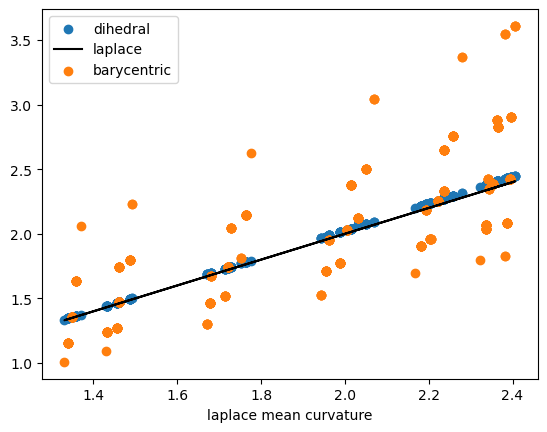

In [12]:
# the two methods for discretizing the mean curvature give similar results

plt.scatter(H_torus_lap, H_torus_dihed, label="dihedral")
plt.plot(H_torus_lap, H_torus_lap, color='k', label="laplace")
plt.scatter(H_torus_lap, H_torus_barycentric, label="barycentric")
plt.xlabel("laplace mean curvature")
plt.legend()

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

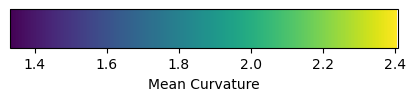

In [15]:
# top plot shows Voronoi, and bottom plot barycentric normalization

meshplot.plot(torus.vertices, hemesh_torus.faces , np.array(H_torus_lap), shading={"wireframe": True})
meshplot.plot(torus.vertices, hemesh_torus.faces , np.array(H_torus_barycentric),
              shading={"wireframe": True})

# add a colorbar
fig, ax = plt.subplots(figsize=(5, 0.5))
sm = plt.cm.ScalarMappable(cmap='viridis',norm=plt.Normalize(vmin=np.array(H_torus_lap).min(),
                                                             vmax=np.array(H_torus_lap).max()))
cbar = fig.colorbar(sm, cax=ax, orientation='horizontal')
cbar.set_label('Mean Curvature')
plt.show()


## Minimal surfaces

As a first example, let's consider a membrane $\mathcal{M}$ whose energy is dominated by surface tension, so the energy is proportional to the membrane area $E_A = \int_{\mathcal{M}} dA$. Note that moving vertices _within_ the plane of the mesh does not change the total area/energy (physically, this is because membranes are fluid in-plane, rather than thin elastic sheets). This has important numerical consequences: we will want to arrange the mesh vertices so as to avoid a highly distorted mesh with very stretched triangles.

A nice algorithm by [Pinkall and Poitier](https://projecteuclid.org/journalArticle/Download?urlId=em%2F1062620735) takes care of this problem. It uses the discretized Laplacian which we already used in the previous notebook for the heat equation. 
The idea is that to minimize the area, the position of a vertex $\mathbf{v}_i$ should be equal to the (geometry-weighted) average of its neighbors, and therefore $\Delta \mathbf{v}_i = 0$. The resulting iterative algorithm works as follows.

1. Given the vertex-positions $\mathbf{v}_i^{(t)}$ at step $t$, compute the cotan-Laplacian matrix $\Delta^{(t)}_{ij}$
2. Solve $\Delta^{(t)}_{ij} \cdot \mathbf{v}_i^{(t+1)} =0$, subject to fixed boundary conditions.

  o flat_tri_ecmc


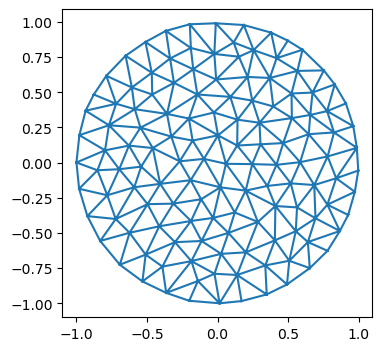

In [16]:
# let's load a simple test mesh

trimesh = TriMesh.read_obj("../test_meshes/disk.obj", dim=3)
hemesh = HeMesh.from_triangles(trimesh.vertices.shape[0], trimesh.faces)

fig = plt.figure(figsize=(4,4))
plt.triplot(*trimesh.vertices[:,:2].T, trimesh.faces)
plt.axis("equal");

In [17]:
# let's impose some boundary conditions on the disk mesh - think of this as finding the shape of a "soap film"
# with a given boundary curve.

bdry_verts = np.where(hemesh.is_bdry)[0]
interior_verts = np.where(~hemesh.is_bdry)[0]

phi_bdry = np.atan2(*trimesh.vertices[bdry_verts, :2].T)
h = 0.5*np.sin(2*phi_bdry)
bdry_pos = np.array(trimesh.vertices[bdry_verts, :])
bdry_pos[:, -1] = h

vertices_bdry_imposed = np.copy(trimesh.vertices)
vertices_bdry_imposed[bdry_verts] = bdry_pos

In [18]:
# the non-optimized membrane is pretty creased

meshplot.plot(vertices_bdry_imposed, hemesh.faces, shading={"wireframe":False}, return_plot=True)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.001874…

In [ ]:
# compute the area of the initial configuration - this is the energy we will minimize
initial_area = geom.get_area(vertices_bdry_imposed, hemesh)
print(f"Initial area: {initial_area:.4f}")

Initial area: 4.3650


In [ ]:
# let's check the cotan-Laplacian gives us the area via A = 1/2 * v^T L v, where v are the vertex positions

L = linops.cotan_laplace_sparse(vertices_bdry_imposed, hemesh)
area_L = -jnp.diag(vertices_bdry_imposed.T.dot(L @ vertices_bdry_imposed)).sum() /2

print(f"Initial area from Laplace operator: {area_L:.4f}")

Initial area from Laplace operator: 4.3650


In [ ]:
# Let's use the iterative Pinkall-Poitier method to find the mininum energy configuration.

vertices_iterated = [np.copy(vertices_bdry_imposed)] 

for t in range(10):
    L = linops.bcoo_to_scipy(linops.cotan_laplace_sparse(vertices_iterated[-1], hemesh)) # compute Laplace matrix

    # impose boundary conditions by splitting the Laplace matrix into interior and boundary vertices
    L_ii = L[interior_verts, :][:, interior_verts] 
    L_ib = L[interior_verts, :][:, bdry_verts]
    bcs = vertices_bdry_imposed[bdry_verts,:]
    
    new_vertices = np.zeros_like(vertices_iterated[-1])
    new_vertices[bdry_verts] = bcs

    solution = np.stack([sparse.linalg.spsolve(-L_ii, L_ib.dot(bc)) for bc in bcs.T], axis=-1)
    # iterate over x/y/z coordinates
    new_vertices[interior_verts] = solution
    vertices_iterated.append(new_vertices)

In [ ]:
# as a result of the optimization, we get an area-minimizing "Pringles" surface

meshplot.plot(vertices_iterated[-1], hemesh.faces, shading={"wireframe":True}, return_plot=True)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.001874…

In [ ]:
final_area = geom.get_area(vertices_iterated[-1], hemesh)
print(f"Initial area: {initial_area:.4f}", f"Final area: {final_area:.4f}")

Initial area: 4.3650 Final area: 3.7981


In [ ]:
# the gradient of the area is very small after optimization:   

(jnp.linalg.norm(jax.grad(geom.get_area)(vertices_iterated[0], hemesh), axis=-1)[interior_verts].mean(),
 jnp.linalg.norm(jax.grad(geom.get_area)(vertices_iterated[-1], hemesh), axis=-1)[interior_verts].mean())

(Array(0.06015605, dtype=float64), Array(0.00068703, dtype=float64))

In [ ]:
# the mean curvature is also very small after optimization, as expected for a minimal surface:
H_laplace = geom.get_mean_curvature_laplace(vertices_iterated[-1], hemesh)
jnp.abs(H_laplace).mean()


Array(0.06962044, dtype=float64)

### Helfrich energy

Next, let's consider a membrane for which the surface tension is negligible. This is the case for many of the lipid bilayer membranes that make up the cell and its interior organelles. Instead, the energy is dominated by _bending_.

The _Helfrich energy_ is an elegant, geometric model of bending energy. It uses the mean and Gaussian curvatures $H, K$ of the surface $\mathcal{M}$. The energy reads:

$$E_H  =\int dA \left( \frac{\kappa_H}{2}(H-H_0)^2 + \kappa_G K \right) $$

If the surface is closed, the $\int K$-term is a topological invariant and can be dropped (and we will do so here). 
A nonzero _spontaneous curvature_ $H_0$ means that the membrane "prefers" to be curved; this can result, for instance, from molecules that bind to the membrane.

In [6]:
# let's load a sphere as a test mesh for the Helfrich energy

trimesh = TriMesh.read_obj("../test_meshes/sphere_fine.obj", dim=3) # sphere_fine sphere

trimesh.vertices -= trimesh.vertices.mean(axis=0)
trimesh.vertices = (trimesh.vertices.T / np.linalg.norm(trimesh.vertices, axis=1)).T

hemesh = HeMesh.from_triangles(trimesh.vertices.shape[0], trimesh.faces)

  o Icosphere


In [7]:
meshplot.plot(trimesh.vertices, hemesh.faces, shading={"wireframe":True})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

In [8]:
# let's define the discrete Helfrich energy.

@jax.jit
def get_helfrich_energy(vertices, args):
    """Compute the discrete Helfrich energy of a triangulated surface. args = (hemesh, H0, kappa)"""
    hemesh, H0, kappa = args
    # the cell areas are needed to discretize the area integral
    cell_areas = geom.get_voronoi_areas_robust(vertices, hemesh)
    #H = geom.get_mean_curvature_laplace(vertices, hemesh)
    H = geom.get_mean_curvature_dihedral(vertices, hemesh, normalize=True)

    return (kappa/2) * ((H - H0) **2 * cell_areas).sum()

In [9]:
args = (hemesh, 0, 1)
# exact helfrich for a sphere is 2*pi, here smaller due to discretization error. The energy is scale invariant.
get_helfrich_energy(trimesh.vertices, args), get_helfrich_energy(2*trimesh.vertices, args), 2*np.pi

(Array(6.29326108, dtype=float64),
 Array(6.29326108, dtype=float64),
 6.283185307179586)

In [10]:
# now, let's deform the sphere and minimize the Helfrich energy to find the equilibrium shape.

deformed_vertices = trimesh.vertices.at[:, 1].add(0.5*trimesh.vertices[:, 1]**3)
deformed_vertices = trimesh.vertices.at[:, 2].add(0.5*trimesh.vertices[:, 0]**3)

print("Minimum vs deformed energy:", get_helfrich_energy(trimesh.vertices, args),
                                     get_helfrich_energy(deformed_vertices, args))

Minimum vs deformed energy: 6.293261081171555 7.118657237550066


In [11]:
meshplot.plot(deformed_vertices, hemesh.faces, shading={"wireframe":True})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

In [12]:
# we can compute the energy gradient using JAX

grad = jax.grad(get_helfrich_energy)(deformed_vertices, args)
normal = geom.get_vertex_normals(deformed_vertices, hemesh)
grad_norm = jnp.linalg.norm(grad, axis=-1)

 # gradient is along normal

(jnp.abs(jnp.linalg.vecdot(grad, normal)) / grad_norm).mean()

Array(0.99466172, dtype=float64)

In [13]:
# the gradient computed via autodiff matches the finite difference approximation

eps = 1e-2
step = eps * normal / jnp.linalg.norm(normal)

grad_autodiff = jnp.sum(grad * step)
grad_fd = (get_helfrich_energy(deformed_vertices+step, args) - get_helfrich_energy(deformed_vertices, args))

1e4*grad_autodiff, 1e4*grad_fd

(Array(-9.05360294, dtype=float64), Array(-9.04334675, dtype=float64))

#### Nonlinear minimization

To minimize the energy, we can use one of many non-linear minimization algorithms, all of which use the gradient $\nabla E_H$ which we can compute using JAX. Here, we use the JAX-based optimization library `optimistix`.

In [14]:
#solver = optimistix.GradientDescent(rtol=1e-8, atol=1e-8, learning_rate=0.5*1e-2)
solver = optimistix.NonlinearCG(rtol=1e-8, atol=1e-8)

y0 = deformed_vertices
args = (hemesh, 0, 1) 

sol = optimistix.minimise(get_helfrich_energy, solver, y0, args, max_steps=10000, throw=False)
vertices_final = sol.value

In [15]:
print("Initial/final/minimal energy:", get_helfrich_energy(y0, args),
                                       get_helfrich_energy(sol.value, args),
                                       get_helfrich_energy(trimesh.vertices, args))

Initial/final/minimal energy: 7.118657237550066 6.300880738246545 6.293261081171555


In [16]:
# displacement from initial condition.

jnp.linalg.norm(y0-sol.value, axis=-1).mean(), jnp.linalg.norm(y0-trimesh.vertices, axis=-1).mean() 

(Array(0.03848122, dtype=float64), Array(0.12507872, dtype=float64))

In [17]:
# after minimization, the deviation from being a perfect sphere is fairly low

center = jnp.average(vertices_final, weights=geom.get_voronoi_areas(vertices_final, hemesh), axis=0)
Rs =  jnp.linalg.norm(vertices_final - center, axis=1)

Rs.std() / Rs.mean()

Array(0.01461819, dtype=float64)

In [18]:
p = meshplot.plot(y0, hemesh.faces, np.array(grad_norm),shading={"wireframe":True}, return_plot=True)
p.add_mesh(sol.value + np.array([0, 0, 3]), hemesh.faces, shading={"wireframe":True})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

1

## Constrained minimization using Penalty and Augmented Lagrangian methods

Much of the physics of membranes arises from balancing the Helfrich bending energy with constraints on the volume $V$ and area $A$ of the membrane. For simplicity, we softly enforce these contrstraints with quadratic penalty terms in the energy:
$$E_P =  \mu_V(V-V_0)^2/(2V_0) + \mu_A(A-A_0)^2/(2A_0)$$


In [19]:
trimesh = TriMesh.read_obj("../test_meshes/sphere_fine.obj", dim=3)
trimesh.vertices -= trimesh.vertices.mean(axis=0)
trimesh.vertices = (trimesh.vertices.T / np.linalg.norm(trimesh.vertices, axis=1)).T

hemesh = HeMesh.from_triangles(trimesh.vertices.shape[0], trimesh.faces)

  o Icosphere


In [20]:
# verify volume and area on the sphere mesh
A_sphere = geom.get_area(trimesh.vertices, hemesh)
V_sphere = geom.get_volume(trimesh.vertices, hemesh)
print(f"Sphere area: {A_sphere:.4f} (exact 4π = {4*jnp.pi:.4f})")
print(f"Sphere volume: {V_sphere:.4f} (exact 4π/3 = {4*jnp.pi/3:.4f})")

Sphere area: 12.5062 (exact 4π = 12.5664)
Sphere volume: 4.1527 (exact 4π/3 = 4.1888)


In [ ]:
@jax.jit
def get_helfrich_energy_with_penalty(vertices, args):
    """Discrete Helfrich energy with quadratic area/volume penalties.
    args = (hemesh, H0, kappa, mu_A, mu_V, A0, V0)"""
    hemesh, H0, kappa, mu_A, mu_V, A0, V0 = args
    E = get_helfrich_energy(vertices, (hemesh, H0, kappa))
    penalty_area = mu_A/2 * (geom.get_area(vertices, hemesh) - A0)**2 / A0
    penalty_volume = mu_V/2 * (geom.get_volume(vertices, hemesh) - V0)**2 / V0**2
    return E + penalty_area + penalty_volume

In [190]:
A0 = geom.get_area(trimesh.vertices, hemesh)
V0 = 0.75 * geom.get_volume(trimesh.vertices, hemesh)
kappa, H0 = 1.0, 0.0
mu_A = 300.0
mu_V = 600.0
args = (hemesh, H0, kappa, mu_A, mu_V, A0, V0)

y0 = trimesh.vertices * np.array([1, 1.05, 1]) # start from stretched configuration to break symmetrty

In [187]:
solver = optimistix.GradientDescent(rtol=1e-8, atol=1e-8, learning_rate=1e-3)
#solver = optimistix.NonlinearCG(rtol=1e-8, atol=1e-8)

sol = optimistix.minimise(get_helfrich_energy_with_penalty, solver, y0, args, max_steps=10000, throw=False)


vertices_final = sol.value

In [188]:
# constraints are approximately satisfied after optimization
geom.get_area(vertices_final, hemesh)/A0, geom.get_volume(vertices_final, hemesh)/V0

(Array(0.99693748, dtype=float64), Array(1.0253752, dtype=float64))

In [189]:
p = meshplot.plot(y0, hemesh.faces, np.array(grad_norm),
                  shading={"wireframe":True}, return_plot=True)

p.add_mesh(sol.value + np.array([3, 0, 0]), hemesh.faces, shading={"wireframe":True})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

1

### Regularization tangential mesh motion

If you play around with the above code, you will notice that it is rather unstable (try using a different minimizer). The reason is the _reparametrization_ invariance of the Helfrich energy we already alluded to - moving vertices in the local tangent plane does not change the energy. Therefore, the triangles of the mesh can easily degenerate during energy minimization, leading to numerical instability. To avoid this, we can add a smoothing step that repositions the vertices tangentially to improve mesh quality between energy minimization steps.

In [191]:
solver = optimistix.NonlinearCG(rtol=1e-8, atol=1e-8)

vertices_smoothed = y0
n_iterations = 50
n_smoothing = 10
smoothing_step_size = 0.1
n_minimization = 100

for i in range(n_iterations):
    sol = optimistix.minimise(get_helfrich_energy_with_penalty, solver, vertices_smoothed, args,
    max_steps=n_minimization, throw=False)
    vertices_smoothed = sol.value
    for j in range(n_smoothing):
        vertices_smoothed = algo.smooth_vertices_laplacian(vertices_smoothed, hemesh, step_size=smoothing_step_size)

In [192]:
geom.get_area(vertices_smoothed, hemesh)/A0, geom.get_volume(vertices_smoothed, hemesh)/V0

(Array(0.99769315, dtype=float64), Array(1.01880222, dtype=float64))

In [193]:
p = meshplot.plot(y0, hemesh.faces, np.array(grad_norm),
                  shading={"wireframe":True}, return_plot=True)

p.add_mesh(vertices_smoothed + np.array([3, 0, 0]), hemesh.faces, shading={"wireframe":True})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

1

### Split normal–tangential optimization

The Helfrich energy is reparametrization-invariant: tangential vertex motion does not change the energy. This means the optimization landscape has flat directions that cause mesh degeneration. To fix this, we **split vertex updates** into two independent sub-problems:

1. **Normal phase**: minimize the physical energy $E_N$ (Helfrich + constraints) by moving vertices only along surface normals.
2. **Tangential phase**: minimize a conformal regularization energy $E_T$ by moving vertices only in the tangent plane.

The key idea is to **reparametrize** each sub-problem: express vertex displacements in the local normal/tangent basis (recomputed each outer iteration), then run a standard unconstrained optimizer on the reduced coordinates. This is compatible with any optimizer (CG, L-BFGS, ...).

**Conformal energy.** For $E_T$, we use the LSCM (Least Squares Conformal Mapping) energy, which penalizes triangle shear relative to a reference configuration but is invariant to uniform area changes:
$$E_{\mathrm{LSCM}} = \sum_f A_f \left(\frac{\mathrm{tr}(C_f)}{2\sqrt{\det C_f}} - 1\right), \qquad C_f = G_0^{-1} G$$
Here, $C_f$ is the Cauchy-Green tensor (a nonlinear measure of strain), computed from $G$, $G_0$ the current and reference metric tensors for each face.

In [ ]:
# --- Mesh energies ---

def get_metric(vertices: Float[jax.Array, "n_faces dim"],
               hemesh: HeMesh) -> Float[jax.Array, "n_faces 2 2"]:
    """Metric tensor (first fundamental form) per triangle."""
    a, b, c = vertices[hemesh.faces.T]
    J = jnp.stack([b - a, c - a], axis=1)
    return jnp.einsum("vix,vjx->vij", J, J)


def get_lscm_energy_density(C: Float[jax.Array, "2 2"]) -> Float[jax.Array, ""]:
    """LSCM conformal energy density from Cauchy-Green tensor C.
    Zero iff the map is conformal (angle-preserving). Scale-invariant.
    """
    return jnp.trace(C) / (2 * jnp.sqrt(jnp.linalg.det(C))) - 1


@jax.jit
def get_conformal_energy(vertices, args):
    """Total LSCM conformal energy. args = (hemesh, metric_ref)"""
    hemesh, metric_ref = args
    areas = geom.get_triangle_areas(vertices, hemesh)
    C = jnp.einsum("fij,fjk->fik", jnp.linalg.inv(metric_ref), get_metric(vertices, hemesh))
    return (areas * jax.vmap(get_lscm_energy_density)(C)).sum()


def get_neo_hookean_energy_density(deformation, mod_bulk, mod_shear):
    """Compute the neo-Hookean energy density from Cauchy-Green deformation tensor.
    See https://en.wikipedia.org/wiki/Neo-Hookean_solid
    """
    I1 = jnp.trace(deformation)
    J = jnp.sqrt(jnp.linalg.det(deformation))
    return mod_shear/2*(I1 - 2 - 2*jnp.log(J)) + mod_bulk/2*(J-1)**2


@jax.jit
def get_neo_hookean_energy(vertices, args):
    """Total neo-Hookean energy. args = (hemesh, metric_ref, mod_bulk, mod_shear)"""
    hemesh, metric_ref, mod_bulk, mod_shear = args
    areas = geom.get_triangle_areas(vertices, hemesh)
    C = jnp.einsum("fij,fjk->fik", jnp.linalg.inv(metric_ref), get_metric(vertices, hemesh))
    return (areas * jax.vmap(lambda c: get_neo_hookean_energy_density(c, mod_bulk, mod_shear))(C)).sum()


In [133]:
# Test: conformal energy is zero for uniform scaling, nonzero for shear

C_identity = jnp.eye(2)
C_scaled = 4 * jnp.eye(2)  # uniform 2× scaling → det=4, tr=4, energy = 4/(2*2)-1 = 0
C_sheared = jnp.array([[1.5, 0.3], [0.3, 0.8]])

print("Identity:", get_lscm_energy_density(C_identity))
print("Uniform scale:", get_lscm_energy_density(C_scaled))
print("Sheared:", get_lscm_energy_density(C_sheared))

Identity: 0.0
Uniform scale: 0.0
Sheared: 0.09153169511537373


As a warmup, let's minimize the physical and parametrization energies by projected gradient descent:
1. Compute the current surface normals $\mathbf{n}$ 
2. Compute the parametrization and physical energy gradients $\nabla E_{LSCM}, \nabla E_N$
3. Move vertices by projecting the physical gradient onto the normal and the parametrization gradient onto the tangential direction:
    $$\mathbf{v} \rightarrow \mathbf{v} + \eta \left(P_\mathbf{n}\cdot \nabla E_N + (\mathbb{I}-P_\mathbf{n})\cdot \nabla E_{LSCM}  \right) $$
    where $P_\mathbf{n} = \mathbf{n} \otimes\mathbf{n}$ is the projecion operator

In [178]:
A0 = geom.get_area(trimesh.vertices, hemesh)
V0 = 0.75 * geom.get_volume(trimesh.vertices, hemesh)
metric_orig = get_metric(trimesh.vertices, hemesh)

kappa, H0 = 1.0, 0.0
mu_A, mu_V = 300.0, 600.0
args_helfrich_penalty = (hemesh, H0, kappa, mu_A, mu_V, A0, V0)

mod_conformal = 1.0 # strength of conformal regularization
args_elastic = (hemesh, metric_orig)

step_size = 0.5*1e-3

@jax.jit
def get_step(vertices):
    grad_helfrich = jax.grad(get_helfrich_energy_with_penalty)(vertices, args_helfrich_penalty)
    grad_elastic = mod_conformal * jax.grad(get_conformal_energy)(vertices, args_elastic)
    normals = geom.get_vertex_normals(vertices, hemesh)
    step = (jax.vmap(trig.project_out_vector)(grad_elastic, normals) +
            jax.vmap(trig.project_on_vector)(grad_helfrich, normals))
    return step

In [179]:
n_iterations = 20000

vertices_initial = trimesh.vertices * np.array([0.95, 1.1, 0.95]) # start from a stretched configuration
v_opt = jnp.copy(vertices_initial)
for t in range(n_iterations):
    v_opt = v_opt - step_size * get_step(v_opt)

In [180]:
# check constraints and mesh quality

grad_helfrich = jax.grad(get_helfrich_energy_with_penalty)(v_opt, args_helfrich_penalty)
print(f"Physical energy gradient norm: {jnp.linalg.norm(grad_helfrich, axis=-1).mean():.4f}")
print(f"A/A0 = {geom.get_area(v_opt, hemesh)/A0:.4f},  V/V0 = {geom.get_volume(v_opt, hemesh)/V0:.4f}")
print(f"Helfrich energy: {get_helfrich_energy(v_opt, (hemesh, H0, kappa)):.4f}")
algo.get_mesh_quality_stats(v_opt, hemesh)

Physical energy gradient norm: 0.0085
A/A0 = 0.9973,  V/V0 = 1.0216
Helfrich energy: 9.2821


{'areas_min': 0.00393,
 'areas_max': 0.02915,
 'areas_cv': 0.72669,
 'max_angle': 89.8132,
 'min_angle': 31.07296,
 'angles_std': 13.80112,
 'n_degenerate': 0,
 'n_total_faces': 1280}

In [181]:
p = meshplot.plot(vertices_initial, hemesh.faces,
                  shading={"wireframe":True}, return_plot=True)

p.add_mesh(v_opt + np.array([3, 0, 0]), hemesh.faces, shading={"wireframe":True})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

1

Now we turn to the more sophisticated method described above: using an arbitrary optimizer for the normal and tangential subproblems.

In [154]:
# --- Reparametrization wrappers ---
# These let any optimizer minimize over normal-only or tangent-only displacements.

def make_normal_energy(energy_fn, v0: Float[jax.Array, "n 3"],
                       normals: Float[jax.Array, "n 3"]):
    """Wrap energy_fn(vertices, args) to optimize over normal heights h ∈ ℝⁿ.

    vertices(h) = v0 + h[:, None] * normals.
    """
    def energy(h, args):
        return energy_fn(v0 + h[:, None] * normals, args)
    return energy


def make_tangential_energy(energy_fn, v0: Float[jax.Array, "n 3"],
                           basis: Float[jax.Array, "n 2 3"]):
    """Wrap energy_fn(vertices, args) to optimize over tangent coords t ∈ ℝⁿˣ².

    vertices(t) = v0 + einsum('vi,vid->vd', t, basis).
    """
    def energy(t, args):
        return energy_fn(v0 + jnp.einsum("vi,vid->vd", t, basis), args)
    return energy


def vertices_from_normal(v0, h, normals):
    """Reconstruct vertices from base + normal displacement."""
    return v0 + h[:, None] * normals


def vertices_from_tangential(v0, t, basis):
    """Reconstruct vertices from base + tangential displacement."""
    return v0 + jnp.einsum("vi,vid->vd", t, basis)

In [155]:
def alternating_minimize(energy_normal_fn, args_normal,
                        energy_tangential_fn, args_tangential,
                        vertices, hemesh,
                        solver_normal=None, solver_tangential=None,
                        n_outer: int = 20,
                        n_inner_normal: int = 100, n_inner_tangential: int = 50,
                        verbose: bool = True):
    """Alternating normal–tangential optimization.

    Parameters
    ----------
    energy_normal_fn : callable
        Physical energy: (vertices, args_normal) → scalar.
    args_normal
        Arguments for the physical energy.
    energy_tangential_fn : callable
        Mesh regularization energy: (vertices, args_tangential) → scalar.
    args_tangential
        Arguments for the regularization energy.
    vertices : Float[Array, "n 3"]
        Initial vertex positions.
    hemesh : HeMesh
        Half-edge mesh connectivity.
    solver_normal, solver_tangential : optimistix solver, optional
        Solvers for normal and tangential phases. Default: NonlinearCG.
    n_outer : int
        Number of alternating iterations.
    n_inner_normal, n_inner_tangential : int
        Max inner steps per phase.
    verbose : bool
        Print diagnostics each iteration.

    Returns
    -------
    vertices : Float[Array, "n 3"]
        Optimized vertex positions.
    history : list[dict]
        Per-iteration diagnostics.
    """
    solver_normal = solver_normal or optimistix.NonlinearCG(rtol=1e-8, atol=1e-8)
    solver_tangential = solver_tangential or optimistix.NonlinearCG(rtol=1e-8, atol=1e-8)
    history = []

    for k in range(n_outer):
        normals = geom.get_vertex_normals(vertices, hemesh)
        basis = geom.get_vertex_tangent_basis(vertices, hemesh)

        # --- Phase 1: normal ---
        E_normal = make_normal_energy(energy_normal_fn, vertices, normals)
        h0 = jnp.zeros(vertices.shape[0])
        sol_n = optimistix.minimise(E_normal, solver_normal, h0, args_normal,
                                    max_steps=n_inner_normal, throw=False)
        vertices = vertices_from_normal(vertices, sol_n.value, normals)

        # --- Phase 2: tangential ---
        E_tangential = make_tangential_energy(energy_tangential_fn, vertices, basis)
        t0 = jnp.zeros((vertices.shape[0], 2))
        sol_t = optimistix.minimise(E_tangential, solver_tangential, t0, args_tangential,
                                    max_steps=n_inner_tangential, throw=False)
        vertices = vertices_from_tangential(vertices, sol_t.value, basis)

        # --- Diagnostics ---
        stats = algo.get_mesh_quality_stats(vertices, hemesh)
        E_phys = float(energy_normal_fn(vertices, args_normal))
        E_conf = float(energy_tangential_fn(vertices, args_tangential))
        record = {"iter": k, "E_phys": E_phys, "E_conf": E_conf, **stats}
        history.append(record)

        if verbose:
            print(f"  {k:3d} | E_phys={E_phys:.4f} | E_conf={E_conf:.6f} | "
                  f"angles=[{stats['min_angle']:.1f}°, {stats['max_angle']:.1f}°] | "
                  f"degen={stats['n_degenerate']}")

    return vertices, history

In [173]:
# --- Demo: deflated sphere with alternating minimization ---

A0 = geom.get_area(trimesh.vertices, hemesh)
V0 = 0.75 * geom.get_volume(trimesh.vertices, hemesh)
metric_ref = get_metric(trimesh.vertices, hemesh)

kappa, H0 = 1.0, 0.0
mu_A, mu_V = 300.0, 600.0
args_helfrich = (hemesh, H0, kappa, mu_A, mu_V, A0, V0)
args_conformal = (hemesh, metric_ref)

# start from a slightly stretched configuration to break spherical symmetry
vertices_initial = trimesh.vertices * np.array([0.95, 1.1, 0.95])

solver_normal =  optimistix.NonlinearCG(rtol=1e-8, atol=1e-8) # NonlinearCG, BFGS OK. LBFGS bad. 
solver_tangential = optimistix.NonlinearCG(rtol=1e-8, atol=1e-8)

#solver_normal =  optimistix.GradientDescent(rtol=1e-8, atol=1e-8, learning_rate=1e-3)
#solver_tangential = optimistix.GradientDescent(rtol=1e-8, atol=1e-8, learning_rate=1e-3)

v_opt, history = alternating_minimize(
    get_helfrich_energy_with_penalty, args_helfrich,
    get_conformal_energy, args_conformal,
    vertices_initial, hemesh,
    solver_normal=solver_normal, solver_tangential=solver_tangential,
    n_outer=30, n_inner_normal=100, n_inner_tangential=100)

    0 | E_phys=64.9981 | E_conf=0.031128 | angles=[51.5°, 70.8°] | degen=0
    1 | E_phys=18.7327 | E_conf=0.020500 | angles=[51.2°, 73.5°] | degen=0
    2 | E_phys=16.7041 | E_conf=0.037603 | angles=[49.5°, 75.0°] | degen=0
    3 | E_phys=14.9701 | E_conf=0.057384 | angles=[50.1°, 74.7°] | degen=0
    4 | E_phys=12.7565 | E_conf=0.121674 | angles=[50.5°, 75.6°] | degen=0
    5 | E_phys=12.0892 | E_conf=0.117630 | angles=[50.4°, 75.8°] | degen=0
    6 | E_phys=10.3361 | E_conf=0.149066 | angles=[50.3°, 74.3°] | degen=0
    7 | E_phys=10.1095 | E_conf=0.146378 | angles=[50.2°, 74.2°] | degen=0
    8 | E_phys=9.9594 | E_conf=0.147099 | angles=[49.7°, 74.3°] | degen=0
    9 | E_phys=9.8032 | E_conf=0.156616 | angles=[49.8°, 73.9°] | degen=0
   10 | E_phys=9.7300 | E_conf=0.160452 | angles=[49.5°, 74.0°] | degen=0
   11 | E_phys=9.7116 | E_conf=0.161121 | angles=[49.6°, 73.9°] | degen=0
   12 | E_phys=9.7073 | E_conf=0.161378 | angles=[49.6°, 73.9°] | degen=0
   13 | E_phys=9.7034 | E_conf

In [174]:
# check constraints and mesh quality
grad_helfrich = jax.grad(get_helfrich_energy_with_penalty)(v_opt, args_helfrich_penalty)
print(f"gradient norm: {jnp.linalg.norm(grad_helfrich, axis=-1).mean():.4f}")
print(f"A/A0 = {geom.get_area(v_opt, hemesh)/A0:.4f},  V/V0 = {geom.get_volume(v_opt, hemesh)/V0:.4f}")
print(f"Helfrich energy: {get_helfrich_energy(v_opt, (hemesh, H0, kappa)):.4f}")
algo.get_mesh_quality_stats(v_opt, hemesh)

gradient norm: 0.0224
A/A0 = 0.9973,  V/V0 = 1.0227
Helfrich energy: 9.2517


{'areas_min': 0.00264,
 'areas_max': 0.07754,
 'areas_cv': 1.37887,
 'max_angle': 74.18301,
 'min_angle': 49.63322,
 'angles_std': 5.00887,
 'n_degenerate': 0,
 'n_total_faces': 1280}

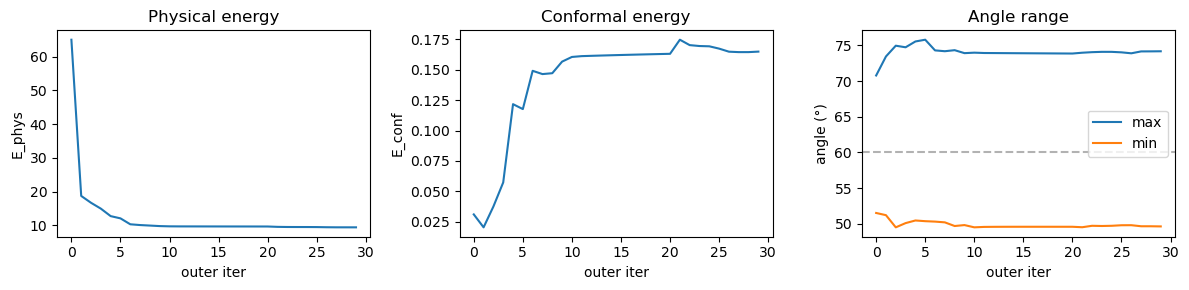

In [175]:
# convergence plot
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
iters = [h["iter"] for h in history]
axes[0].plot(iters, [h["E_phys"] for h in history])
axes[0].set(xlabel="outer iter", ylabel="E_phys", title="Physical energy")
axes[1].plot(iters, [h["E_conf"] for h in history])
axes[1].set(xlabel="outer iter", ylabel="E_conf", title="Conformal energy")
axes[2].plot(iters, [h["max_angle"] for h in history], label="max")
axes[2].plot(iters, [h["min_angle"] for h in history], label="min")
axes[2].axhline(60, ls="--", color="k", alpha=0.3)
axes[2].set(xlabel="outer iter", ylabel="angle (°)", title="Angle range")
axes[2].legend()
fig.tight_layout()

In [176]:
# visualize initial and optimized shape
p = meshplot.plot(vertices_initial, hemesh.faces, shading={"wireframe": True}, return_plot=True)
p.add_mesh(v_opt + np.array([3, 0, 0]), hemesh.faces, shading={"wireframe": True})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

1

In [115]:
# same thing with mass-matrix preconditioning
v_opt_pc, history_pc = alternating_minimize(
    get_helfrich_energy_with_penalty, args_helfrich,
    get_conformal_energy, args_conformal,
    vertices_initial, hemesh,
    n_outer=30, n_inner_normal=200, n_inner_tangential=50,
    precondition=True, verbose=False)

print(f"A/A0 = {geom.get_area(v_opt_pc, hemesh)/A0:.4f},  V/V0 = {geom.get_volume(v_opt_pc, hemesh)/V0:.4f}")
print(f"Helfrich energy: {get_helfrich_energy(v_opt_pc, (hemesh, H0, kappa)):.4f}")
print(f"Mesh quality: {algo.get_mesh_quality_stats(v_opt_pc, hemesh)}")

A/A0 = 1.0750,  V/V0 = 0.8323
Helfrich energy: 55.9940
Mesh quality: {'areas_min': 0.0003, 'areas_max': 0.23678, 'areas_cv': 1.91076, 'max_angle': 167.46362, 'min_angle': 3.13522, 'angles_std': 12.99505, 'n_degenerate': 2, 'n_total_faces': 1280}


In [ ]:
# to do: addd "energies" module with varrious mesh based energies

In [ ]:
# something is going wrong with the gradient of the Helfrich energy - it loooks like it depends strongly
# on the local coordination number, with more displacement near the 5-fold coordinated vertices.
# this is clearly visible when computing a smaller number of gradient descent steps (say 1000)

## Below - work in progress, ignore

### Augmented Lagrangian method

A more systematic way to include the area and volume constraints is via two Lagrange multipliers $\lambda, p$, surface tension and pressure:   

$$\mathcal{L} = E_H - \lambda (A-A_0) -p (V-V_0) $$

Minimization under the boundary constraint is equivalent to stationarity of the Lagrangian:

$$\nabla_\lambda \mathcal{L} = 0 \quad \mathrm{and} \quad \nabla_{\mathbf{v}} \mathcal{L} = 0 $$

Finding these stationary points - the aim of _numerical constrained minimization_ - can be quite challenging.
If the number of constraints (here, $2$) is small compared to the number of variables (here, $3\#\mathrm{vertices}$), _augmented Lagrangian methods_ are a suitable approach [(Nocedal & Wright, 2006)](https://link.springer.com/book/10.1007/978-0-387-40065-5).


Let's combine all constraints into a vectorial function $\mathbf{c}(\mathbf{x})$ so that $\mathbf{c}(\mathbf{x})=0$ when the constraint is fulfilled. All Lagrange multipliers are packaged into a vector $\lambda$. The _augmented Lagrangian_ $\mathcal{L}_A$ adds a quadratic penalty for constraint violations, with strength $\mu$:

$$\mathcal{L}_A = E(\mathbf{x}) -\lambda^T \cdot\mathbf{c}(\mathbf{x}) + \mu |\mathbf{c}(\mathbf{x})|^2$$

The AL method now iteratively (1) minimizes $\mathcal{L}_A$ w.r.t. to the variables $\mathbf{x}$ and (2) updates the Lagrange multiplier $\lambda$ and penalty strength $\mu$. The big advantage of the AL method compared to the naive approach of using only a penalty for constraint violation is that $\mu$ does not need to be increased to large values, which generally leads to numerical difficulties.

In pseudo-code, the AL method works like this:
```
Initialize μ > 0, tolerance τ > 0, starting points x and λ:
for k = 0, 1, 2, . . .
    Update x: x = minimizer of LA(·, λ; μ) with tolerance τ, starting from x   
    if convergence test for Lagrangian stationarity is satisfied:
        return x
    Update Lagrange multipliers: λ =  λ - μ * c(x)
    Increase penalty parameter μ
    Select new tolerance
```

In [275]:
@jax.jit
def augmented_lagrangian(vertices, args):
    """Augmented Lagrangian: E_H - λᵀc + (μ/2)|c|², where c = [A-A0, V-V0]."""
    hemesh, H0, kappa, lam, mu, A0, V0 = args
    E = get_helfrich_energy(vertices, (hemesh, H0, kappa))
    c = jnp.array([get_area(vertices, hemesh) - A0,
                    get_volume(vertices, hemesh) - V0])
    area_penalty = ((geom.get_triangle_areas(vertices, hemesh)-0.146)**2).sum()
    return E - lam @ c + (mu / 2) * (c @ c) + area_penalty

In [289]:
def al_minimize(vertices, hemesh, H0, kappa, A0, V0,
                mu0=1.0, mu_growth=1.5, max_outer=10, tol=1e-4, max_inner=500):
    """Augmented Lagrangian method for constrained Helfrich energy minimization."""
    lam = jnp.zeros(2)
    mu = mu0
    solver = optimistix.NonlinearCG(rtol=1e-5, atol=1e-5)

    for k in range(max_outer):
        args = (hemesh, H0, kappa, lam, mu, A0, V0)
        sol = optimistix.minimise(augmented_lagrangian, solver, vertices, args,
                                  max_steps=max_inner, throw=False)
        vertices = sol.value

        A = get_area(vertices, hemesh)
        V = get_volume(vertices, hemesh)
        c = jnp.array([A - A0, V - V0])
        E = get_helfrich_energy(vertices, (hemesh, H0, kappa))

        # stationarity of the Lagrangian (μ=0): ∇_v L = 0 and ∇_λ L = -c = 0
        lagrangian_args = (hemesh, H0, kappa, lam, 0.0, A0, V0)
        grad_v = jax.grad(augmented_lagrangian)(vertices, lagrangian_args)
        grad_norm = jnp.sqrt(jnp.sum(grad_v**2) + jnp.sum(c**2))

        print(f"  iter {k:2d} | E_H={E:.4f} | A={A:.4f} (target {A0:.4f}) | "
              f"V={V:.4f} (target {V0:.4f}) | |∇L|={grad_norm:.2e} | μ={mu:.1f}")

        if grad_norm < tol:
            print("Converged!")
            break

        lam = lam - mu * c
        mu = mu * mu_growth

    return vertices, lam

In [290]:
# minimize Helfrich energy of a sphere with constrained area and reduced volume (deflated)

A0 = get_area(trimesh.vertices, hemesh)
V0 = 0.6 * get_volume(trimesh.vertices, hemesh)
kappa, H0 = 1.0, 0.0

# small perturbation to break spherical symmetry
key = jax.random.PRNGKey(0)
v0 = trimesh.vertices + 0.02 * jax.random.normal(key, trimesh.vertices.shape)

print(f"Target: A0={A0:.4f}, V0={V0:.4f}")
print(f"Initial: A={get_area(v0, hemesh):.4f}, V={get_volume(v0, hemesh):.4f}")

v_opt, lam_opt = al_minimize(v0, hemesh, H0, kappa, A0, V0)

Target: A0=11.6659, V0=2.1952
Initial: A=11.6992, V=3.6646
  iter  0 | E_H=6.5829 | A=11.1221 (target 11.6659) | V=3.4060 (target 2.1952) | |∇L|=1.33e+00 | μ=1.0
  iter  1 | E_H=6.5841 | A=11.1126 (target 11.6659) | V=3.4011 (target 2.1952) | |∇L|=1.34e+00 | μ=1.5
  iter  2 | E_H=6.6155 | A=11.1184 (target 11.6659) | V=3.3931 (target 2.1952) | |∇L|=1.37e+00 | μ=2.2
  iter  3 | E_H=6.6155 | A=11.1184 (target 11.6659) | V=3.3931 (target 2.1952) | |∇L|=4.39e+00 | μ=3.4
  iter  4 | E_H=6.6155 | A=11.1184 (target 11.6659) | V=3.3931 (target 2.1952) | |∇L|=1.49e+00 | μ=5.1
  iter  5 | E_H=12.7387 | A=11.7214 (target 11.6659) | V=2.5791 (target 2.1952) | |∇L|=1.71e+02 | μ=7.6
  iter  6 | E_H=12.7386 | A=11.7214 (target 11.6659) | V=2.5791 (target 2.1952) | |∇L|=1.77e+02 | μ=11.4
  iter  7 | E_H=12.7386 | A=11.7214 (target 11.6659) | V=2.5791 (target 2.1952) | |∇L|=1.75e+02 | μ=17.1
  iter  8 | E_H=12.7386 | A=11.7214 (target 11.6659) | V=2.5791 (target 2.1952) | |∇L|=1.73e+02 | μ=25.6
  iter 

In [291]:
# visualize the deflated shape

E_final = get_helfrich_energy(v_opt, (hemesh, H0, kappa))
E_sphere = get_helfrich_energy(trimesh.vertices, (hemesh, H0, kappa))
print(f"Helfrich energy: sphere={E_sphere:.4f}, deflated={E_final:.4f}")
print(f"Final area: {get_area(v_opt, hemesh):.4f} (target {A0:.4f})")
print(f"Final volume: {get_volume(v_opt, hemesh):.4f} (target {V0:.4f})")
print(f"Lagrange multipliers (tension, pressure): {lam_opt}")

meshplot.plot(v_opt, hemesh.faces, shading={"wireframe": True})

Helfrich energy: sphere=6.5831, deflated=12.7386
Final area: 11.7214 (target 11.6659)
Final volume: 2.5791 (target 2.1952)
Lagrange multipliers (tension, pressure): [  1.66632623 -54.26580124]


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0167619…

### Non-linear optimization

We have found the desired solution, but using a pretty "custom" algorithm. Let's try to use a more general-purpose strategy for constrained non-linear optimization. To do so, we use the method of Lagrange multipliers, and define the Lagrangian

$$\mathcal{L} = \int_{\mathcal{M}} dA - \int_{\partial\mathcal{M}} \lambda(s)^T \cdot (\mathbf{b}(s) - \mathbf{v}(s))$$

where the first term is the mesh area, and the second term forces vertex positions $\mathbf{v}(s)$ at the boundary to lie at the targets $\mathbf{b}(s)$.

Minimization under the boundary constraint is equivalent to stationarity of the Lagrangian:

$$\nabla_\lambda \mathcal{L} = 0 \quad \mathrm{and} \quad \nabla_{\mathbf{v}} \mathcal{L} = 0 $$

We can attempt to solve this non-linear system of equations using the Newton method, or using non-linear least squares.

In [16]:
def get_lagrangian(vertices, lagrange_mult, bdry_verts, bdry_pos, hemesh):
    """Compute the Lagrangian for the area minimization problem with boundary conditions."""
    area = geom.get_triangle_areas(vertices, hemesh).sum()
    lagrange_term = jax.vmap(jnp.dot)(lagrange_mult, vertices[bdry_verts] - bdry_pos).sum()
    return area - lagrange_term

@jax.jit
def stationarity_condition(y, args):
    vertices, lagrange_mult = y
    v_term = jax.grad(get_lagrangian, argnums=0)(vertices, lagrange_mult, *args)
    l_term = jax.grad(get_lagrangian, argnums=1)(vertices, lagrange_mult, *args)

    return (v_term, l_term)


In [17]:
args = (jnp.array(bdry_verts), jnp.array(bdry_pos), hemesh)

vertices_initial = jnp.array(vertices_bdry_imposed)
lagrange_mult_initial = 1*jnp.ones_like(bdry_pos)

In [18]:
_ = stationarity_condition((vertices_initial, lagrange_mult_initial), args)
get_lagrangian(vertices_initial, lagrange_mult_initial, *args)

Array(4.36495664, dtype=float64)

In [26]:
solver = optimistix.LevenbergMarquardt(rtol=1e-8, atol=1e-8, ) 

y0 = (vertices_initial, lagrange_mult_initial)
sol = optimistix.root_find(stationarity_condition, solver, y0, args, max_steps=50, throw=False)
vertices_final, lagrange_mult_final = sol.value

In [27]:
vertices_final.max(axis=0), vertices_final.min(axis=0) # that doesn't look good

(Array([1.00112636, 0.98954106, 0.49702471], dtype=float64),
 Array([-0.99658605, -0.99661577, -0.4918562 ], dtype=float64))

In [28]:
meshplot.plot(vertices_final, hemesh.faces, shading={"wireframe":True}, return_plot=True)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0022701…